# Análisis de reseñas de `mindfulchef.com`

En este notebook realizo un análisis completo de las reseñas de **mindfulchef.com** dentro de su sector, **Restaurants & Bars**, con el objetivo de responder a las preguntas planteadas en el caso práctico: si el sentimiento es mayoritariamente positivo o negativo, qué temas aparecen en las reseñas, cómo se comporta cada tema en términos de sentimiento y en qué aspectos la empresa está mejor o peor que la competencia del mismo sector.  
El enfoque que sigo está alineado con el enunciado del caso práctico y con la estructura sugerida en la plantilla de presentación.

## Objetivos del notebook

1. Cargar y revisar el dataset completo.
2. Filtrar mi empresa objetivo y el sector al que pertenece.
3. Limpiar el texto de las reseñas para reducir ruido.
4. Aplicar un modelo de **sentimiento** más sólido que uno puramente basado en reglas.
5. Extraer **topics** de las reseñas.
6. Combinar **topic + sentimiento** a nivel de reseña.
7. Comparar **mindfulchef.com vs competencia del sector**.
8. Identificar **fortalezas, debilidades y áreas de mejora**.


## 1) Librerías

En esta primera parte importo todas las librerías que voy a necesitar.  
He dejado el notebook preparado para trabajar con un enfoque robusto:

- **pandas / numpy** para manipulación de datos.
- **matplotlib / seaborn** para visualización.
- **nltk** para stopwords.
- **transformers** para el modelo de sentimiento.
- **BERTopic** como opción principal para topics.
- **NMF** como plan B por si en algún entorno BERTopic diera problemas de instalación.

Si me faltase alguna librería, podría instalarla con comandos como estos:

```bash
!pip install pandas numpy matplotlib seaborn nltk scikit-learn transformers torch wordcloud
!pip install bertopic sentence-transformers umap-learn hdbscan
```


In [2]:
!pip install nltk scikit-learn transformers torch wordcloud

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   --------------------------------- ------ 1.3/1.6 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 6.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 8.0 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.0 MB 7.9 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 7.7 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 7.7 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/8.0 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 6.7 MB/s  0:00:01
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ------ --------------------------------- 1.6/10.2 MB 8.0 MB/s eta 0:00:02
   ------------- ------------------

In [3]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.7 MB 9.4 MB/s eta 0:00:01
   ------------ --------------------------- 3.1/9.7 MB 8.5 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.7 MB 8.3 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.7 MB 8.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 8.1 MB/s  0:00:01

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- ---------------------

In [4]:
!pip install bertopic sentence-transformers umap-learn hdbscan

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 571.3/571.3 kB 6.2 MB/s  0:00:00
   ---------------------------------------- 0.0/670.6 kB ? eta -:--:--
   ---------------------------------------- 670.6/670.6 kB 4.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 5.5 MB/s eta 0:00:07
   - -------------------------------------- 1.8/38.1 MB 4.3 MB/s eta 0:00:09
   - -------------------------------------- 1.8/38.1 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.1/38.1 MB 2.9 MB/s eta 0:00:13
   -- ------------------------------------- 2.1/38.1 MB 2.9 MB/s eta 0:00:13
   -- ------------------------------------- 2.6/38.1 MB 2.0 MB/s eta 0:00:18
   --- ------------------------------------ 3.1/38.1 MB 2.1 MB/s eta 0:00:17
   ---- ---------

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

from transformers import pipeline

# Intento importar BERTopic. Si no estuviera disponible, más adelante usaré NMF como alternativa.
try:
    from bertopic import BERTopic
    BERTOPIC_AVAILABLE = True
except Exception:
    BERTOPIC_AVAILABLE = False

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False

# Descargo recursos de NLTK solo si hicieran falta
nltk.download("stopwords", quiet=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")


## 2) Configuración

Aquí defino los parámetros principales del análisis.  
He fijado ya la empresa elegida, **mindfulchef.com**, y dejo el resto de parámetros agrupados para poder ajustar fácilmente el notebook si más adelante quisiera probar otra empresa o cambiar el número de topics.


In [5]:
# En esta celda lo que toca es fijar los parámetros principales de todo el análisis, probablemente haya que cambiar esta ruta dependiendo de donde tenga cada uno el dataset.
DATA_PATH = r'C:\Users\Alvar\Downloads\trustpilot-reviews-123k.csv'

TARGET_COMPANY = "mindfulchef.com"
MAX_ROWS = None          # Lo dejo en None para usar todo el dataset; si quisiera probar rápido podría poner, por ejemplo, 20000
N_TOPICS = 8             # Número inicial de topics que quiero explorar
TOP_WORDS = 10           # Número de palabras representativas por topic
MIN_COMPANY_REVIEWS = 100

# Modelo de sentimiento
SENTIMENT_MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3) Carga de datos

En este bloque cargo el dataset completo y hago una primera comprobación de estructura.  
Mi idea aquí es validar que las columnas coinciden con lo esperado antes de empezar a filtrar y transformar.


In [4]:
# Cargamos el dataset completo
df = pd.read_csv(DATA_PATH)

if MAX_ROWS is not None:
    df = df.head(MAX_ROWS).copy()

print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]}")
display(df.head(3))
print(df.dtypes)


Número de filas: 123,181
Número de columnas: 6


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, double thickness soft cotton towelling drying rugs, with their unique, practical...",Great quality dog drying robe although…,Great quality dog drying robe although had to wait a while for it to come back into stock,5
1,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, double thickness soft cotton towelling drying rugs, with their unique, practical...",Really prompt service,"Really prompt service, The sofa covers have not moved since being put on despite the efforts of three cocker spaniels!Helpful staff who delayed delivery on request because I would be away for deli...",5
2,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, double thickness soft cotton towelling drying rugs, with their unique, practical...",Life saver,I’ve purchased first of those coats in May2020. Still goes strong although my girl is not with us anymore her little sister is still using it. I’ve bought a limited edition this year as a Christma...,5


category       object
company        object
description    object
title          object
review         object
stars           int64
dtype: object


## 4) Revisión inicial del dataset

Antes de entrar en el análisis, compruebo:
- valores nulos,
- número de empresas,
- número de sectores,
- distribución de reseñas por empresa.

Esto me sirve para tener contexto y justificar después mis decisiones de filtrado.


In [6]:
# Ahora revisaremos la estructura general, nulos y cardinalidad
print("Columnas:", list(df.columns))
print("\nValores nulos por columna:")
display(df.isna().sum().to_frame("nulos"))

print(f"Número de empresas distintas: {df['company'].nunique():,}")
print(f"Número de sectores distintos: {df['category'].nunique():,}")

reviews_per_company = df.groupby("company").size().sort_values(ascending=False)
print("\nResumen de reseñas por empresa:")
display(reviews_per_company.describe())


Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']

Valores nulos por columna:


,nulos
category,0
company,0
description,0
title,0
review,0
stars,0


Número de empresas distintas: 1,680
Número de sectores distintos: 22

Resumen de reseñas por empresa:


count    1680.000000
mean       73.322024
std        30.669449
min         1.000000
25%        46.000000
50%        89.000000
75%       100.000000
max       100.000000
dtype: float64

In [7]:
# En este paso toca verificar específicamente que mi empresa objetivo existe y tiene 100 reseñas
company_mask = df["company"].str.lower() == TARGET_COMPANY.lower()
target_exists = company_mask.sum()

print(f"Reseñas encontradas para {TARGET_COMPANY}: {target_exists}")

if target_exists == 0:
    raise ValueError(f"No he encontrado la empresa {TARGET_COMPANY} en el dataset.")

if target_exists < MIN_COMPANY_REVIEWS:
    print("Aviso: la empresa tiene menos de 100 reseñas, convendría revisar la elección.")


Reseñas encontradas para mindfulchef.com: 100


## 5) Identificación del sector y creación de subconjuntos

Tomás insistió en que la comparación debe hacerse **dentro del mismo sector**, no contra todo el dataset.  
Por eso, en este punto:
- identifico el sector de **mindfulchef.com**,
- creo un subconjunto con todas las empresas de ese sector,
- y separo también las reseñas de mi empresa objetivo.


In [8]:
# Identificamos el sector principal de mi empresa y construyo mis subconjuntos de trabajo
TARGET_SECTOR = df.loc[company_mask, "category"].mode().iloc[0]

df_sector = df[df["category"] == TARGET_SECTOR].copy()
df_company = df[df["company"].str.lower() == TARGET_COMPANY.lower()].copy()
df_competitors = df_sector[df_sector["company"].str.lower() != TARGET_COMPANY.lower()].copy()

print(f"Sector de {TARGET_COMPANY}: {TARGET_SECTOR}")
print(f"Rango total del sector: {df_sector.shape[0]:,} reseñas")
print(f"Reseñas de mi empresa: {df_company.shape[0]:,}")
print(f"Reseñas de la competencia del sector: {df_competitors.shape[0]:,}")
print(f"Empresas en el sector: {df_sector['company'].nunique():,}")
print(f"Empresas competidoras: {df_competitors['company'].nunique():,}")


Sector de mindfulchef.com: Restaurants & Bars
Rango total del sector: 5,204 reseñas
Reseñas de mi empresa: 100
Reseñas de la competencia del sector: 5,104
Empresas en el sector: 100
Empresas competidoras: 99


## 6) Exploración rápida del texto

Antes de limpiar, observo qué tipo de texto tengo delante.  
Esta revisión me ayuda a detectar:
- longitudes de reseña,
- uso de signos,
- saltos de línea,
- posibles caracteres raros,
- o cualquier patrón que me interese contemplar en la función de limpieza.


In [9]:
# Observo algunas reseñas reales para entender mejor el tipo de texto que voy a limpiar
sample_reviews = df_company["review"].dropna().sample(5, random_state=RANDOM_STATE).tolist()

for i, review in enumerate(sample_reviews, start=1):
    print(f"--- Review {i} ---")
    print(review[:700], "\n")


--- Review 1 ---
Terrible experience, another rip off company that re starts your subscription and charges £102 for shopping I don’t need.  Never received an email like they said.  Avoid at all costs  

--- Review 2 ---
Like: good recipes, easy to follow. Clean, quality ingredients. Dislike: not enough choice of recipes. Still expensive with the discount. Even if most of the packaging can be recycled, the huge cardboard box is not very convenient for people with limited recycling space/bins/access to centres. 

--- Review 3 ---
Way too expensive, especially for 1person. Also every other subscription is a minimum of 2, yet again single  subscription is a minimum of 3 meals which is unfair! Delivery was originally free, then went to 2.99 with notice  then 3.99 then 4.99 without notice. Company passing on all increases to customers! Will not continue purchase as is which is a shame 

--- Review 4 ---
Switched to mindful chef from Gousto to have better more sustainability produce but I see

In [10]:
# Analizamos la longitud de las reseñas y de los títulos porque esto me da contexto sobre la riqueza textual
df["review_len"] = df["review"].astype(str).str.len()
df["title_len"] = df["title"].astype(str).str.len()

print("Longitud de review:")
display(df["review_len"].describe())

print("\nLongitud de title:")
display(df["title_len"].describe())


Longitud de review:


count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64


Longitud de title:


count    123181.000000
mean         30.629651
std          14.160631
min           2.000000
25%          21.000000
50%          32.000000
75%          38.000000
max         200.000000
Name: title_len, dtype: float64

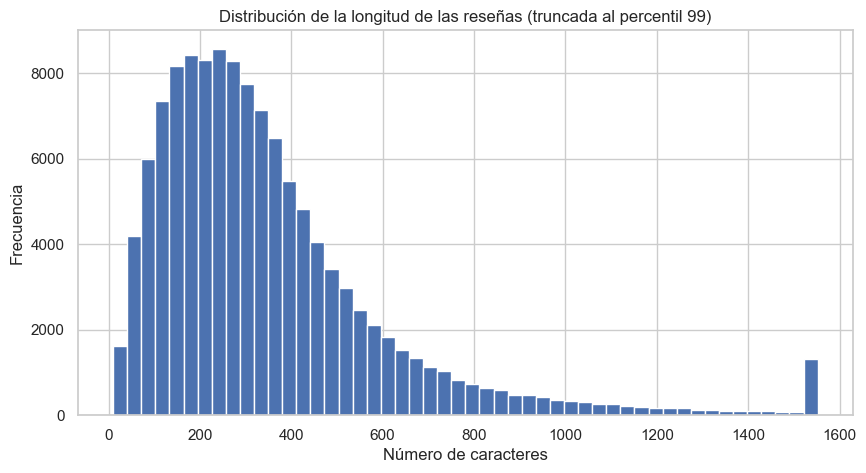

In [11]:
# Aqui se visualiza la distribución de longitud de las reseñas para ver si predominan textos muy cortos o largos
review_lengths = df["review"].astype(str).str.len()

plt.figure(figsize=(10, 5))
plt.hist(review_lengths.clip(upper=review_lengths.quantile(0.99)), bins=50)
plt.title("Distribución de la longitud de las reseñas (truncada al percentil 99)")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()


## 7) Limpieza de texto

En esta fase construyo una función de limpieza relativamente conservadora.  
Mi objetivo no es dejar el texto perfecto lingüísticamente, sino **reducir ruido** sin destruir información útil.

Decisiones de limpieza:
- paso todo a minúsculas,
- elimino URLs,
- elimino saltos de línea,
- reduzco puntuación y números,
- elimino espacios redundantes,
- elimino stopwords,
- normalizo caracteres extraños.

No utilizo las estrellas para entrenar el sentimiento, porque mi intención es que el modelo infiera el sentimiento desde el propio texto.


In [12]:
# Vamos a preparar la lista de stopwords en inglés porque todas las reseñas del dataset están en inglés
stop_words = set(stopwords.words("english"))

def normalize_text(text):
    """Normalizamos los caracteres unicode para reducir ruido visual."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8", errors="ignore")
    return text

def clean_text(text):
    """Ahora aplicamos la tipica limpieza básica y bastante segura para análisis de NLP."""
    text = normalize_text(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # Quito URLs
    text = re.sub(r"\n|\r|\t", " ", text)               # Quito saltos de línea y tabulaciones
    text = re.sub(r"[^a-z\s]", " ", text)                 # Quito signos, emojis y números
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 2]
    return " ".join(tokens)

# Ahora creamos una columna de texto completo combinando título y review para aprovechar ambas fuentes
df_sector["full_text"] = (
    df_sector["title"].fillna("").astype(str).str.strip() + " " +
    df_sector["review"].fillna("").astype(str).str.strip()
).str.strip()

df_company["full_text"] = (
    df_company["title"].fillna("").astype(str).str.strip() + " " +
    df_company["review"].fillna("").astype(str).str.strip()
).str.strip()

df_competitors["full_text"] = (
    df_competitors["title"].fillna("").astype(str).str.strip() + " " +
    df_competitors["review"].fillna("").astype(str).str.strip()
).str.strip()

# Aplicamos la limpieza
df_sector["clean_text"] = df_sector["full_text"].apply(clean_text)
df_company["clean_text"] = df_company["full_text"].apply(clean_text)
df_competitors["clean_text"] = df_competitors["full_text"].apply(clean_text)

display(df_company[["title", "review", "clean_text"]].head(3))


,title,review,clean_text
53635,High-quality gluten-free goodness!,"As someone who is gluten intolerant and looking for nutritious, high-quality ingredients in their daily meals, Mindful Chef has more than delivered with what they have to offer. I also love to coo...",high quality gluten free goodness someone gluten intolerant looking nutritious high quality ingredients daily meals mindful chef delivered offer also love cook find always learning new things oppo...
53636,Thank you : FOR EVERYTHING!,"I have a very restrictive diet. Joining Mindful Chef has literally been a lifesaver in relation to what I can eat. The meals are fantastic and by ordering the meals that I have had to prepare, I h...",thank everything restrictive diet joining mindful chef literally lifesaver relation eat meals fantastic ordering meals prepare learnt cook choice great app fantastic importantly choose want food d...
53637,Except and very tasty,Except and very tasty. Would like more fibre eg beans instead of rice though,except tasty except tasty would like fibre beans instead rice though


In [13]:
# En este paso eliminamos las posibles filas que hayan quedado vacías tras la limpieza
df_sector = df_sector[df_sector["clean_text"].str.strip() != ""].copy()
df_company = df_company[df_company["clean_text"].str.strip() != ""].copy()
df_competitors = df_competitors[df_competitors["clean_text"].str.strip() != ""].copy()

print(f"Sector tras limpieza: {df_sector.shape[0]:,}")
print(f"Empresa tras limpieza: {df_company.shape[0]:,}")
print(f"Competencia tras limpieza: {df_competitors.shape[0]:,}")


Sector tras limpieza: 5,204
Empresa tras limpieza: 100
Competencia tras limpieza: 5,104


## 8) EDA de negocio: estrellas y empresas del sector

Aunque no utilice las estrellas como entrada del modelo de sentimiento, sí me interesa analizarlas como **contexto de negocio**.  
Aquí observo:
- cómo se distribuyen las stars de mi empresa,
- qué tamaño tiene cada competidor en número de reseñas,
- y cómo se sitúa mindfulchef.com dentro del sector.


,mindfulchef,sector
stars,,
1,0.2,0.198885
2,0.2,0.149500
3,0.2,0.149885
4,0.2,0.174289
5,0.2,0.327440


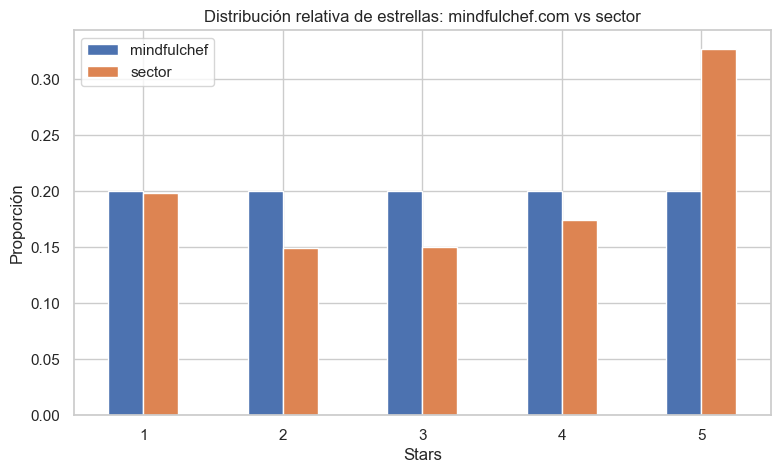

In [14]:
# Vamos a comparar la distribución de estrellas entre mi empresa y el conjunto del sector
company_star_dist = (
    df_company["stars"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("mindfulchef")
)

sector_star_dist = (
    df_sector["stars"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("sector")
)

star_compare = pd.concat([company_star_dist, sector_star_dist], axis=1).fillna(0)
display(star_compare)

star_compare.plot(kind="bar", figsize=(9, 5))
plt.title("Distribución relativa de estrellas: mindfulchef.com vs sector")
plt.xlabel("Stars")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()


,company,n_reviews
0,hellofresh.co.uk,100
1,hungryhorse.co.uk,100
2,gousto.co.uk,100
3,berwickshellfish.com,100
4,www.brewersfayre.co.uk,100
5,www.chefonline.co.uk,100
6,www.buzzcateringsupplies.com,100
7,www.burgerking.co.uk,100
8,www.eversfieldorganic.co.uk,100
9,www.harvester.co.uk,100


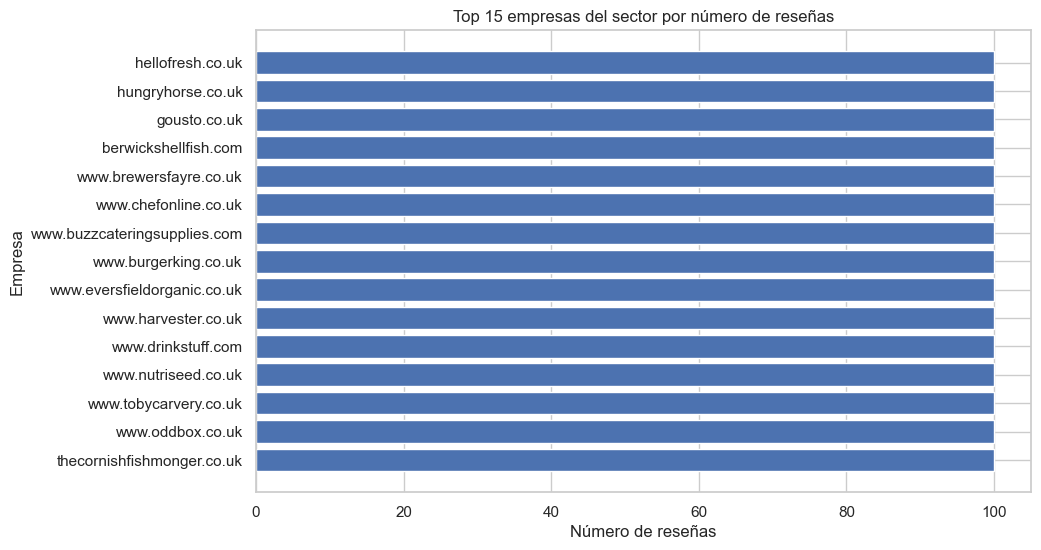

In [15]:
# Tenemos que ver cuáles son las empresas con más reseñas dentro del sector
sector_companies = (
    df_sector.groupby("company")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_reviews")
)

display(sector_companies.head(15))

plt.figure(figsize=(10, 6))
plt.barh(sector_companies.head(15)["company"][::-1], sector_companies.head(15)["n_reviews"][::-1])
plt.title("Top 15 empresas del sector por número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Empresa")
plt.show()


## 9) Modelo de sentimiento

En esta parte aplico un modelo de sentimiento basado en **Transformers**, que es más sólido que un enfoque puramente basado en reglas.  
Mi idea aquí es etiquetar cada reseña como positiva o negativa a partir del texto completo.

Notas importantes:
- proceso el texto original (`full_text`) para no perder matices semánticos,
- limito la longitud máxima porque los modelos tipo BERT tienen una ventana de entrada finita,
- y después convierto la salida a una variable binaria para poder agregar resultados por topic y por empresa.


In [16]:
# Aquí cargamos el pipeline de sentimiento una sola vez para reutilizarlo en todo el análisis, esto sirve para evitar cargar el modelo repetidamente.
sentiment_pipe = pipeline(
    task="sentiment-analysis",
    model=SENTIMENT_MODEL_NAME,
    tokenizer=SENTIMENT_MODEL_NAME,
    truncation=True
)

def get_sentiment_label(text):
    """Vamos a obetener la etiqueta de sentimiento del modelo para un texto dado."""
    if pd.isna(text) or str(text).strip() == "":
        return np.nan
    result = sentiment_pipe(str(text)[:512])[0]
    return result["label"]

def get_sentiment_score(text):
    """Y ahora obtenemos la confianza del modelo para usarla como apoyo interpretativo."""
    if pd.isna(text) or str(text).strip() == "":
        return np.nan
    result = sentiment_pipe(str(text)[:512])[0]
    return result["score"]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2840.41it/s]


In [17]:
#Para este paso aplicaremos el modelo primero a mi empresa y luego al resto del sector
df_company["sentiment_label"] = df_company["full_text"].apply(get_sentiment_label)
df_company["sentiment_score"] = df_company["full_text"].apply(get_sentiment_score)

df_sector["sentiment_label"] = df_sector["full_text"].apply(get_sentiment_label)
df_sector["sentiment_score"] = df_sector["full_text"].apply(get_sentiment_score)

# Y debemos crear una versión binaria para facilitar agregaciones posteriores
label_to_binary = {"POSITIVE": 1, "NEGATIVE": 0}
df_company["sentiment_binary"] = df_company["sentiment_label"].map(label_to_binary)
df_sector["sentiment_binary"] = df_sector["sentiment_label"].map(label_to_binary)

display(df_company[["full_text", "sentiment_label", "sentiment_score"]].head(5))


,full_text,sentiment_label,sentiment_score
53635,"High-quality gluten-free goodness! As someone who is gluten intolerant and looking for nutritious, high-quality ingredients in their daily meals, Mindful Chef has more than delivered with what the...",POSITIVE,0.999612
53636,Thank you : FOR EVERYTHING! I have a very restrictive diet. Joining Mindful Chef has literally been a lifesaver in relation to what I can eat. The meals are fantastic and by ordering the meals tha...,POSITIVE,0.999852
53637,Except and very tasty Except and very tasty. Would like more fibre eg beans instead of rice though,POSITIVE,0.994010
53638,Eating mindfully… Delicious easy and quick recipes that mean it isn’t a chore to cook dinner after a day at work and is expanding my repertoire. Portions are a perfect size so I’m not hungry but I...,POSITIVE,0.999820
53639,"Amazing recipes Amazing recipes, quick and easy to make, healthy and delicious.",POSITIVE,0.999887


,mindfulchef,sector
Negative reviews,0.62,0.525942
Positive reviews,0.38,0.474058


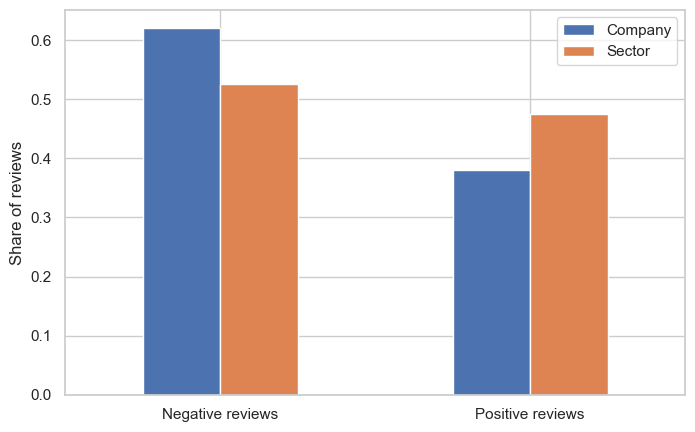

In [18]:
# En este paso vamos a resumir el sentimiento global de la empresa y del sector
company_sentiment_summary = (
    df_company["sentiment_label"]
    .value_counts(normalize=True)
    .rename("mindfulchef")
)

sector_sentiment_summary = (
    df_sector["sentiment_label"]
    .value_counts(normalize=True)
    .rename("sector")
)

sentiment_compare = pd.concat([company_sentiment_summary, sector_sentiment_summary], axis=1).fillna(0)
sentiment_compare.index = ["Negative reviews", "Positive reviews"]
display(sentiment_compare)

sentiment_compare.plot(kind="bar", figsize=(8, 5))
plt.title("")
plt.xlabel("")
plt.legend(["Company", "Sector"], title="")
plt.ylabel("Share of reviews")
plt.xticks(rotation=0)
plt.show()


## 10) Extracción de topics

Aquí extraigo los temas principales que aparecen en las reseñas de **mindfulchef.com**.  
Mi opción principal es **BERTopic**, porque suele generar topics más semánticos y más interpretables.  
Aun así, dejo preparado un **fallback con NMF**, porque así me aseguro de que el notebook siga siendo ejecutable incluso si la instalación de BERTopic da problemas.

Decisión metodológica:
- extraigo los topics sobre la empresa objetivo,
- y después proyecto esa información a nivel interpretativo para comparar con la competencia.


In [19]:
# Para esto vamos a definir una función auxiliar para interpretar topics de forma consistente
def build_topic_name(words, top_n=4):
    words = [w for w in words if w and w != "-1"]
    return " / ".join(words[:top_n])

if BERTOPIC_AVAILABLE:
    print("BERTopic está disponible. Voy a usar BERTopic como método principal.")

    topic_model = BERTopic(
        nr_topics=N_TOPICS,
        top_n_words=TOP_WORDS,
        calculate_probabilities=False,
        verbose=False
    )

    company_topics, company_probs = topic_model.fit_transform(df_company["clean_text"].tolist())
    df_company["topic_id"] = company_topics

    topic_info = topic_model.get_topic_info()
    display(topic_info.head(10))

    # En esta ocasión construiremos un diccionario topic_id -> nombre interpretable
    topic_name_map = {}
    for topic_id in topic_info["Topic"].tolist():
        if topic_id == -1:
            topic_name_map[topic_id] = "outliers / miscellaneous"
        else:
            words = [w for w, _ in topic_model.get_topic(topic_id)]
            topic_name_map[topic_id] = build_topic_name(words)
            
    # Aquí renombro manualmente los topics para que sean más interpretables en negocio
    manual_topic_names = {
        -1: "Other mixed comments",
        0: "Product quality and recipes",
        1: "Orders, delivery and customer service"
    }

    topic_name_map.update(manual_topic_names)

    df_company["topic_name"] = df_company["topic_id"].map(topic_name_map)

else:
    print("Si BERTopic no está disponible usaremos NMF como alternativa estable.")

    vectorizer = TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90
    )

    X_company = vectorizer.fit_transform(df_company["clean_text"])

    nmf_model = NMF(
        n_components=N_TOPICS,
        random_state=RANDOM_STATE,
        init="nndsvda",
        max_iter=500
    )

    W = nmf_model.fit_transform(X_company)
    H = nmf_model.components_

    topic_ids = W.argmax(axis=1)
    df_company["topic_id"] = topic_ids

    feature_names = np.array(vectorizer.get_feature_names_out())
    topic_name_map = {}

    for topic_idx, topic_weights in enumerate(H):
        top_words = feature_names[np.argsort(topic_weights)[::-1][:TOP_WORDS]].tolist()
        topic_name_map[topic_idx] = build_topic_name(top_words)

    # Aquí renombro manualmente los topics para que sean más interpretables en negocio
    manual_topic_names = {
        -1: "Other mixed comments",
        0: "Product quality and recipes",
        1: "Orders, delivery and customer service"
    }

    topic_name_map.update(manual_topic_names)
    df_company["topic_name"] = df_company["topic_id"].map(topic_name_map)

display(df_company[["clean_text", "topic_id", "topic_name"]].head(10))


BERTopic está disponible. Voy a usar BERTopic como método principal.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2712.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_meals_quality_mindful_chef,"[meals, quality, mindful, chef, food, delivery, good, expensive, ingredients, box]",[good option one person claim good option single person actually still get double amount dry goods meat get single portion understand practical every item shipping half lemon getting two vegetable...
1,0,41,0_recipes_good_chef_mindful,"[recipes, good, chef, mindful, ingredients, like, quality, easy, great, really]",[good ingredients beginner friendly time saving recipes varied ingredients good quality even vitality discount price high someone limited cooking experience process isnt always straightforward oft...
2,1,27,1_order_meals_cancelled_service,"[order, meals, cancelled, service, subscription, box, one, received, food, customer]",[knows order didnt arrive incredibly excited start journey mindful chef painfully choosing meals order many looked sounded great placed order paid ensured food house would used delivery date inser...


,clean_text,topic_id,topic_name
53635,high quality gluten free goodness someone gluten intolerant looking nutritious high quality ingredients daily meals mindful chef delivered offer also love cook find always learning new things oppo...,0,Product quality and recipes
53636,thank everything restrictive diet joining mindful chef literally lifesaver relation eat meals fantastic ordering meals prepare learnt cook choice great app fantastic importantly choose want food d...,0,Product quality and recipes
53637,except tasty except tasty would like fibre beans instead rice though,-1,Other mixed comments
53638,eating mindfully delicious easy quick recipes mean isnt chore cook dinner day work expanding repertoire portions perfect size hungry feel healthier,0,Product quality and recipes
53639,amazing recipes amazing recipes quick easy make healthy delicious,0,Product quality and recipes
53640,impressed impressed mindful chef far food ethical good quality recipes easy follow website delivery efficient stress free makes daily life alot easier,0,Product quality and recipes
53641,get pay mindful chef lovely fresh tasty ingredients great recipes like way get recipes week booklet keep prices higher recipe box companies feels like treat affordable may able sustain night week ...,0,Product quality and recipes
53642,really enjoyed recipes really enjoyed recipes nutritional therapist tried mindful chef want able recommend recipe box company clients arent great cooking fridge impressed portion size satiating fl...,0,Product quality and recipes
53643,mindful chef post surgery meal planning mindful chef provides healthy nutritious flavoursome recipes produce also performed miracle enabling kitchen phobic husband face challenge cooking meals whi...,0,Product quality and recipes
53644,like food quality like food quality tastes flavours portion size packaging would prefer less little plastic packets things maybe offer reduced price option supply ingredients like honey soya stock...,0,Product quality and recipes


,topic_name,n_reviews
0,Product quality and recipes,41
1,Other mixed comments,32
2,"Orders, delivery and customer service",27


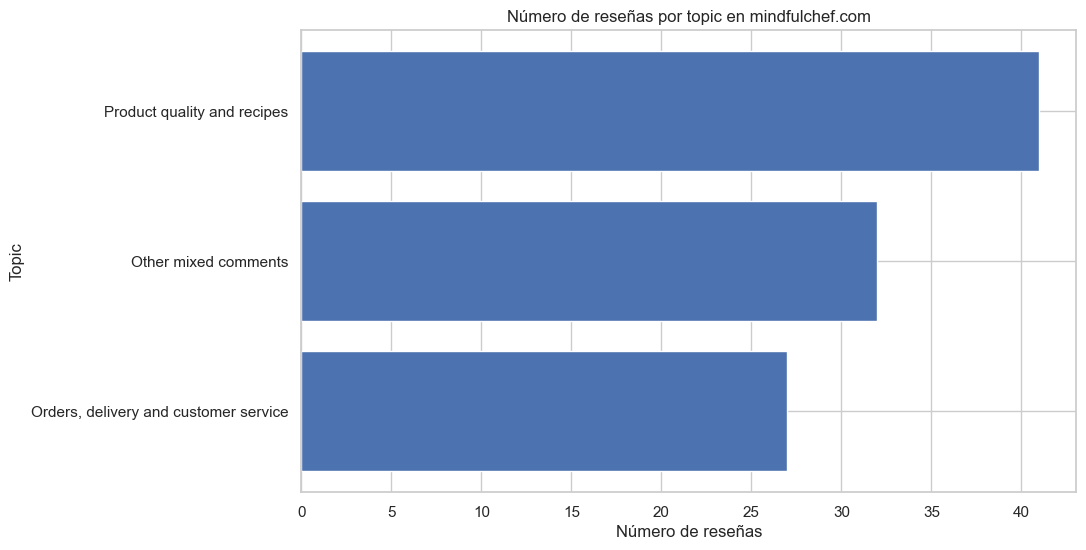

In [20]:
# Tenemos también que observar el tamaño de cada topic dentro de mi empresa
company_topic_counts = (
    df_company["topic_name"]
    .value_counts()
    .reset_index()
)
company_topic_counts.columns = ["topic_name", "n_reviews"]

display(company_topic_counts)

plt.figure(figsize=(10, 6))
plt.barh(company_topic_counts["topic_name"][::-1], company_topic_counts["n_reviews"][::-1])
plt.title("Número de reseñas por topic en mindfulchef.com")
plt.xlabel("Número de reseñas")
plt.ylabel("Topic")
plt.show()


## 11) Palabras representativas por topic

Además del nombre resumido de cada topic, me interesa visualizar el vocabulario más representativo de cada uno.  
Esto me ayuda a comprobar si los topics tienen sentido de negocio y si están recogiendo temas como calidad, servicio, entrega, precio o experiencia general.


In [23]:
# En esta celda voy a mostrar las palabras clave por topic para interpretarlos mejor
if BERTOPIC_AVAILABLE:
    print("Palabras clave por topic (BERTopic):\n")
    for topic_id, topic_name in sorted(topic_name_map.items(), key=lambda x: str(x[0])):
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:TOP_WORDS]]
        print(f"Topic {topic_id} | {topic_name}")
        print(words)
        print("-" * 90)
else:
    print("Palabras clave por topic (NMF):\n")
    for topic_id, topic_name in sorted(topic_name_map.items(), key=lambda x: x[0]):
        print(f"Topic {topic_id} | {topic_name}")
        print(topic_name.split(" / "))
        print("-" * 90)


Palabras clave por topic (BERTopic):

Topic 0 | Product quality and recipes
['recipes', 'good', 'chef', 'mindful', 'ingredients', 'like', 'quality', 'easy', 'great', 'really']
------------------------------------------------------------------------------------------
Topic 1 | Orders, delivery and customer service
['order', 'meals', 'cancelled', 'service', 'subscription', 'box', 'one', 'received', 'food', 'customer']
------------------------------------------------------------------------------------------


## 12) Asignación de topics a la competencia

Para poder comparar mi empresa con el sector, necesito una forma coherente de asignar topics también al resto de empresas del sector.

- Si uso **BERTopic**, transformo las reseñas del sector con el modelo ya ajustado en mi empresa.
- Si uso **NMF**, proyecto el sector con el vectorizador y el modelo NMF entrenados en mi empresa.

Esta decisión me permite comparar usando el **mismo espacio temático**, lo cual hace que la comparación sea mucho más consistente.


In [24]:
# Vamos a proyectar el resto del sector sobre el mismo modelo temático aprendido en mi empresa
if BERTOPIC_AVAILABLE:
    sector_topics, _ = topic_model.transform(df_sector["clean_text"].tolist())
    df_sector["topic_id"] = sector_topics
    df_sector["topic_name"] = df_sector["topic_id"].map(topic_name_map).fillna("Other mixed comments")
else:
    X_sector = vectorizer.transform(df_sector["clean_text"])
    sector_W = nmf_model.transform(X_sector)
    sector_topic_ids = sector_W.argmax(axis=1)
    df_sector["topic_id"] = sector_topic_ids
    df_sector["topic_name"] = df_sector["topic_id"].map(topic_name_map)

display(df_sector[["company", "clean_text", "topic_id", "topic_name"]].head(10))


,company,clean_text,topic_id,topic_name
49908,itsu.com,big guy moses works big guy moses works itsu gatwick airport kind gentle welcoming made journey even better putting smile thanks moses continue shine light others,-1,Other mixed comments
49909,itsu.com,great experience itsu thanks great experience itsu thanks hospitality moses gatwick airport south terminal,-1,Other mixed comments
49910,itsu.com,itsu virgins enjoyed lovely itsu virgins enjoyed lovely first time experience itsu liverpool street staff exceptionally good helping navigate way ordering process food hot tasty efficiently produc...,-1,Other mixed comments
49911,itsu.com,itsu brunswick centre three cheers lovely staff itsu brunswick centre camden extremely nice sushi place staff helpful especially ornella wojciech taught operate technology scan app claim butterfli...,-1,Other mixed comments
49912,itsu.com,itsu reading gate great itsu reading gate clean restaurant friendly staff food quick great,-1,Other mixed comments
49913,itsu.com,tasty food year old son loves restaurant chain ordered rice box absolutely loved normally complains eating vegetables way cooked presented meant happy eat veg decor beautiful,-1,Other mixed comments
49914,itsu.com,ate itsu restaurant brunswick centre ate itsu restaurant brunswick centre naast excellent food service extra special smiles genuine interest tourists visiting first time quick efficient friendly,-1,Other mixed comments
49915,itsu.com,excellent service excellent service lovely food highly recommend,-1,Other mixed comments
49916,itsu.com,phenomenal food itsu great menu really fair prices sushi phenomenal always fresh also love healthier option fast food chains restaurants atmosphere inside dine always great criticism including min...,-1,Other mixed comments
49917,itsu.com,visiting brixton branch visiting brixton branch since opening year ago enjoy convenience grabbing hot meal less mins away office especially love poached egg add dish order tends top would highly r...,-1,Other mixed comments


## 13) Sentimiento por topic

Este es uno de los bloques más importantes del proyecto.  
Aquí combino dos dimensiones:
- **de qué habla la reseña** (topic),
- **con qué tono habla** (sentimiento).

Con esto puedo detectar si, por ejemplo:
- un topic es mayoritariamente positivo,
- otro es una fuente clara de frustración,
- o si hay temas concretos donde mi empresa destaca frente al resto del sector.


In [25]:
# Ahora calculamos el sentimiento medio por topic para mi empresa
company_topic_sentiment = (
    df_company.groupby("topic_name")
    .agg(
        n_reviews=("topic_name", "size"),
        positive_rate=("sentiment_binary", "mean")
    )
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

company_topic_sentiment["negative_rate"] = 1 - company_topic_sentiment["positive_rate"]

display(company_topic_sentiment)


,topic_name,n_reviews,positive_rate,negative_rate
0,Product quality and recipes,41,0.756098,0.243902
1,Other mixed comments,32,0.218750,0.781250
2,"Orders, delivery and customer service",27,0.000000,1.000000


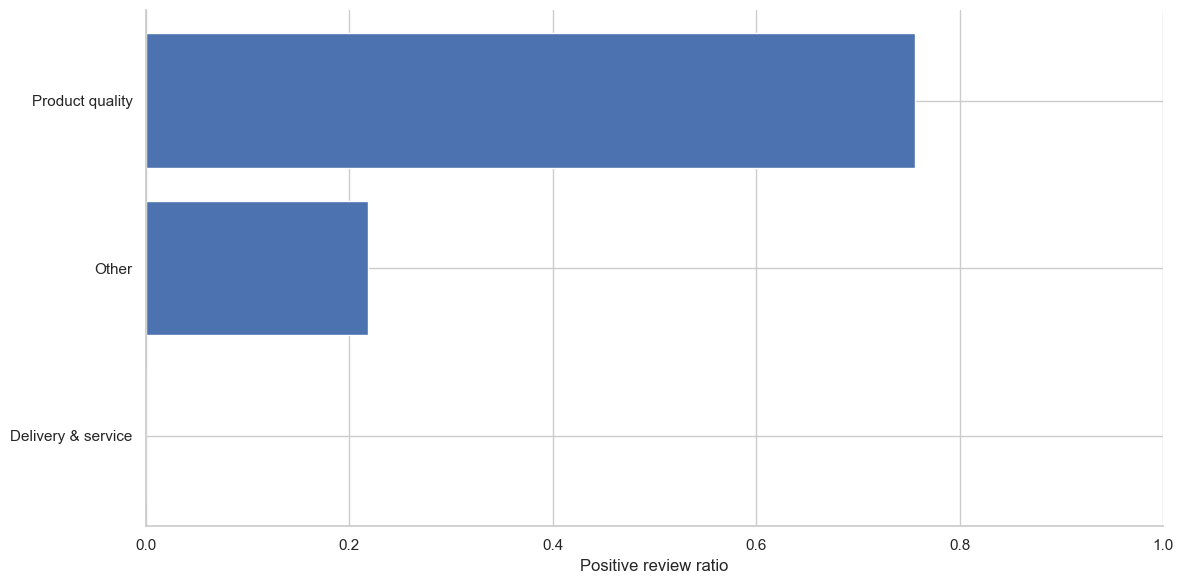

In [26]:
# Tenemos que visualizar la tasa positiva por topic de mi empresa para entender cuáles son los temas que generan más satisfacción y cuáles podrían ser áreas de mejora. Esto es clave para la estrategia de producto y marketing.
plot_df = company_topic_sentiment.sort_values("positive_rate", ascending=True).copy()

plot_df["topic_name"] = plot_df["topic_name"].replace({
    "Product quality and recipes": "Product quality",
    "Other mixed comments": "Other",
    "Orders, delivery and customer service": "Delivery & service"
})

plt.figure(figsize=(12, 6))
plt.barh(plot_df["topic_name"], plot_df["positive_rate"])

plt.title("")
plt.xlabel("Positive review ratio")
plt.ylabel("")

plt.xlim(0, 1)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [27]:
# Filtramos reseñas negativas del topic de delivery
delivery_negative = df_company[
    (df_company["topic_name"] == "Orders, delivery and customer service") &
    (df_company["sentiment_binary"] == 0)
]

print("Número de reseñas negativas en delivery:", len(delivery_negative))
delivery_negative["clean_text"].head(10)

Número de reseñas negativas en delivery: 27


53663    best meal box around pricey weve mindful chef box weeks positives tried new foods includes good quality ingredients reduced food waste took mental load thinking dinner especially coeliac recipes g...
53677    venison chicken chewy venison chicken received meals tough venison especially past nice tender venison last box delivered open top open bottom started come apart meat options becoming limited mind...
53679    complaint tried year stop complaint tried year stop mindful chef sending advertising rental property stressed mail advertising someone never lived address despite returning mail messages online aa...
53690                     poor courier service happened ging deliver due arrive used couriers web site request delivery left round back property request ignored even though website registered request accepted
53692    worth money arranged subscription receiving vouchers friends meals brilliant seemed extremely expensive provided ordered meals family recipe booklet provid

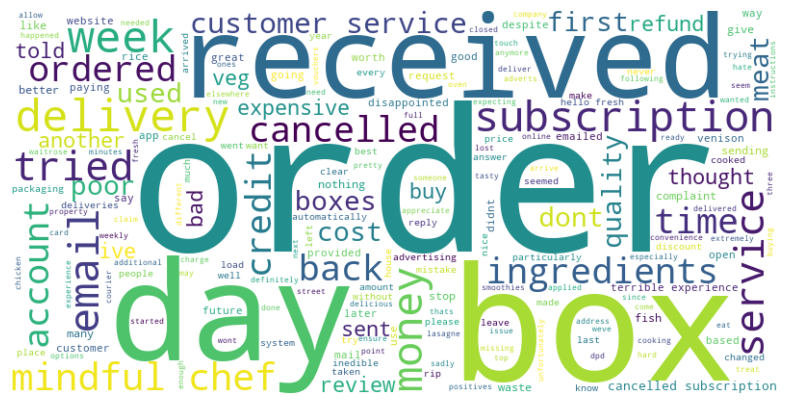

In [28]:
# Hacemos un wordcloud para las reseñas negativas. Esta decisión se hace a raiz de realizar la presentación en clase y comentar con Tomás que sería interesante ver que topics hay negativos y posibles soluciones.
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(delivery_negative["clean_text"].dropna())
stopwords = {
    "meal", "meals", "food", "recipe", "recipes",
    "one", "would", "also",
    "get", "got", "really", "even", "still"
}
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("")
plt.show()

In [29]:
# Vemos un conteo de las palabras más comunes en las reseñas negativas.
from collections import Counter

words = " ".join(delivery_negative["clean_text"]).split()
common_words = Counter(words).most_common(15)

common_words

[('meals', 29),
 ('order', 23),
 ('box', 15),
 ('service', 14),
 ('subscription', 14),
 ('food', 13),
 ('cancelled', 13),
 ('one', 12),
 ('recipes', 10),
 ('received', 10),
 ('delivery', 10),
 ('customer', 10),
 ('mindful', 9),
 ('would', 9),
 ('chef', 8)]

In [30]:
# Sacamos un sample de reseñas negativas para leerlas y entender mejor qué problemas específicos están reportando los clientes en el tema de delivery y servicio.
delivery_negative["clean_text"].sample(5, random_state=42)

53703    expecting better quality expecting better quality ingredients thought beef would grass fed steaks cooking instructions incorrect emailed missing oven temperature missed veg fish timings switched c...
53717    used order loads smoothies used order loads smoothies service good changed lot leaving delivery longer charging buying others thought would give today one soggy box brown squashed bananas waste po...
53704    jury ready meals early review based one week plant based bundle ready meals one meal broken transit resulting sharp plastic shards packaging meal thankfully refunded delicious chickpea based meals...
53727    food fresh sending extra packages days ordered food fish particular day shelf life got ponged bit got email say getting another order days received box even week later emailed back say moneys take...
53663    best meal box around pricey weve mindful chef box weeks positives tried new foods includes good quality ingredients reduced food waste took mental load thi

## 14) Comparación con la competencia del sector

En esta parte comparo **mindfulchef.com** contra el resto de empresas de **Restaurants & Bars** usando los mismos topics.

Este bloque responde de forma directa a la pregunta de negocio:
- ¿En qué temas estamos mejor que la competencia?
- ¿En qué temas estamos peor?


In [31]:
# Separamos empresa y competencia dentro del dataframe del sector ya topicado
df_sector["group"] = np.where(
    df_sector["company"].str.lower() == TARGET_COMPANY.lower(),
    "mindfulchef",
    "sector_competitors"
)

topic_sentiment_compare = (
    df_sector.groupby(["group", "topic_name"])
    .agg(
        n_reviews=("topic_name", "size"),
        positive_rate=("sentiment_binary", "mean")
    )
    .reset_index()
)

pivot_compare = topic_sentiment_compare.pivot(
    index="topic_name",
    columns="group",
    values="positive_rate"
).reset_index()

pivot_compare["gap_vs_sector"] = (
    pivot_compare["mindfulchef"] - pivot_compare["sector_competitors"]
)

pivot_compare = pivot_compare.sort_values("gap_vs_sector", ascending=False)
display(pivot_compare)


group,topic_name,mindfulchef,sector_competitors,gap_vs_sector
2,Product quality and recipes,1.000000,0.916667,0.083333
1,Other mixed comments,0.389474,0.491972,-0.102498
0,"Orders, delivery and customer service",0.000000,0.119658,-0.119658


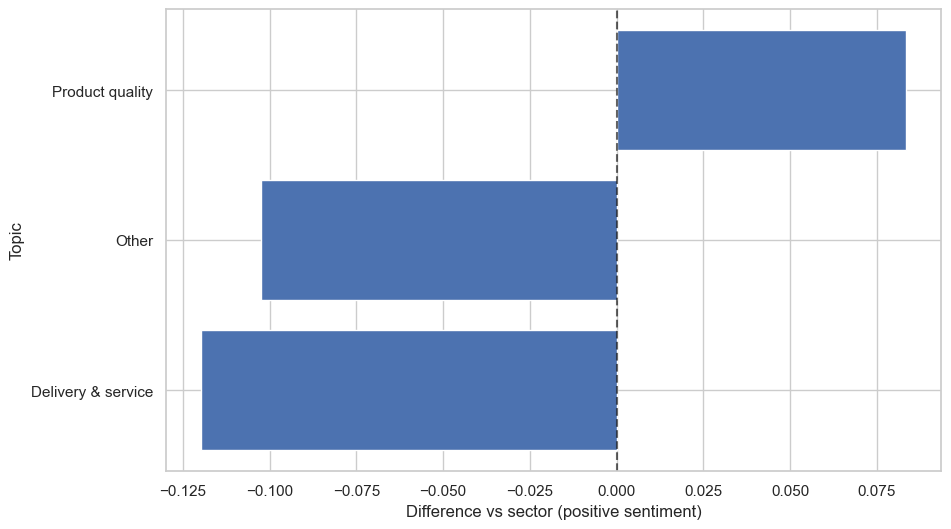

In [32]:
# Visualizamos el gap por topic para ver de forma inmediata fortalezas y debilidades
gap_plot = pivot_compare.sort_values("gap_vs_sector", ascending=True)
gap_plot["topic_name"] = gap_plot["topic_name"].replace({
    "Product quality and recipes": "Product quality",
    "Other mixed comments": "Other",
    "Orders, delivery and customer service": "Delivery & service"
})
plt.figure(figsize=(10, 6))
plt.barh(gap_plot["topic_name"], gap_plot["gap_vs_sector"])
plt.title("")
plt.xlabel("Difference vs sector (positive sentiment)")
plt.ylabel("Topic")
plt.axvline(0, linestyle="--", color="black", alpha=0.6)

plt.show()


## 15) Mejores y peores áreas relativas

A partir del gap de sentimiento, identifico:
- los topics donde **mindfulchef.com** está mejor que la competencia,
- y los topics donde está peor.

Este paso es especialmente útil para convertir el análisis técnico en **insights accionables de negocio**.


In [33]:
# En esta ocasión vamos a extraer fortalezas y debilidades relativas de forma muy directa
top_strengths = pivot_compare.sort_values("gap_vs_sector", ascending=False).head(3)
top_weaknesses = pivot_compare.sort_values("gap_vs_sector", ascending=True).head(3)

print("Fortalezas relativas frente al sector:")
display(top_strengths)

print("Debilidades relativas frente al sector:")
display(top_weaknesses)


Fortalezas relativas frente al sector:


group,topic_name,mindfulchef,sector_competitors,gap_vs_sector
2,Product quality and recipes,1.000000,0.916667,0.083333
1,Other mixed comments,0.389474,0.491972,-0.102498
0,"Orders, delivery and customer service",0.000000,0.119658,-0.119658


Debilidades relativas frente al sector:


group,topic_name,mindfulchef,sector_competitors,gap_vs_sector
0,"Orders, delivery and customer service",0.000000,0.119658,-0.119658
1,Other mixed comments,0.389474,0.491972,-0.102498
2,Product quality and recipes,1.000000,0.916667,0.083333


## 16) Ejemplos reales de reseñas por topic

Para no quedarme solo en métricas agregadas, reviso ejemplos concretos de reseñas dentro de algunos topics.  
Esto me ayuda a validar si la interpretación cuantitativa encaja con el contenido real del texto.


In [34]:
# Buscaremos ejemplos de reseñas por topic para validar cualitativamente mi lectura y entender mejor qué tipo de comentarios hay detrás de cada tema, esto es fundamental para no quedarnos solo en la interpretación cuantitativa.
topics_to_inspect = company_topic_sentiment["topic_name"].head(3).tolist()

for topic in topics_to_inspect:
    print(f"\n{'='*120}")
    print(f"TOPIC: {topic}")
    print(f"{'='*120}")

    examples = df_company.loc[df_company["topic_name"] == topic, ["title", "review", "sentiment_label"]].head(3)
    display(examples)



TOPIC: Product quality and recipes


,title,review,sentiment_label
53635,High-quality gluten-free goodness!,"As someone who is gluten intolerant and looking for nutritious, high-quality ingredients in their daily meals, Mindful Chef has more than delivered with what they have to offer. I also love to coo...",POSITIVE
53636,Thank you : FOR EVERYTHING!,"I have a very restrictive diet. Joining Mindful Chef has literally been a lifesaver in relation to what I can eat. The meals are fantastic and by ordering the meals that I have had to prepare, I h...",POSITIVE
53638,Eating mindfully…,Delicious easy and quick recipes that mean it isn’t a chore to cook dinner after a day at work and is expanding my repertoire. Portions are a perfect size so I’m not hungry but I feel healthier.,POSITIVE



TOPIC: Other mixed comments


,title,review,sentiment_label
53637,Except and very tasty,Except and very tasty. Would like more fibre eg beans instead of rice though,POSITIVE
53648,Quality of food and all small details are noticed,"Hello, I have spent some years now noticing your adverts in various places and thought, ""Hmm, nice concept, but I can cook and don’t really need a service like that."" Nevertheless, a small leaflet...",POSITIVE
53650,At last,"At last - a meal prep company that actually fills you up, doesn't contain 60% green beans, and doesn't contain a load of emulsifiers and preservatives in the pastes or powders while pretending to ...",NEGATIVE



TOPIC: Orders, delivery and customer service


,title,review,sentiment_label
53663,Best meal box around but pricey,"So we’ve had the Mindful Chef box for 3 weeks. The positives - tried some new foods, includes good quality ingredients, reduced our food waste, took the mental load out of thinking what to have fo...",NEGATIVE
53677,The venison and chicken chewy,"The venison and chicken received for 2 of the meals were tough, the venison especially, in the past we have had some nice tender venison. Last box delivered was ‘open’, top open and bottom started...",NEGATIVE
53679,COMPLAINT Tried for a year to stop…,COMpLAINT Tried for a year to stop mindful chef sending advertising to a rental property !!!!! No no no ! Stressed with all the mail advertising for someone who has never lived at my address … des...,NEGATIVE


## 17) Nube de palabras opcional

La nube de palabras no sustituye al análisis de topics, pero puede servir como apoyo visual para la presentación.  
La utilizo solo como recurso complementario.


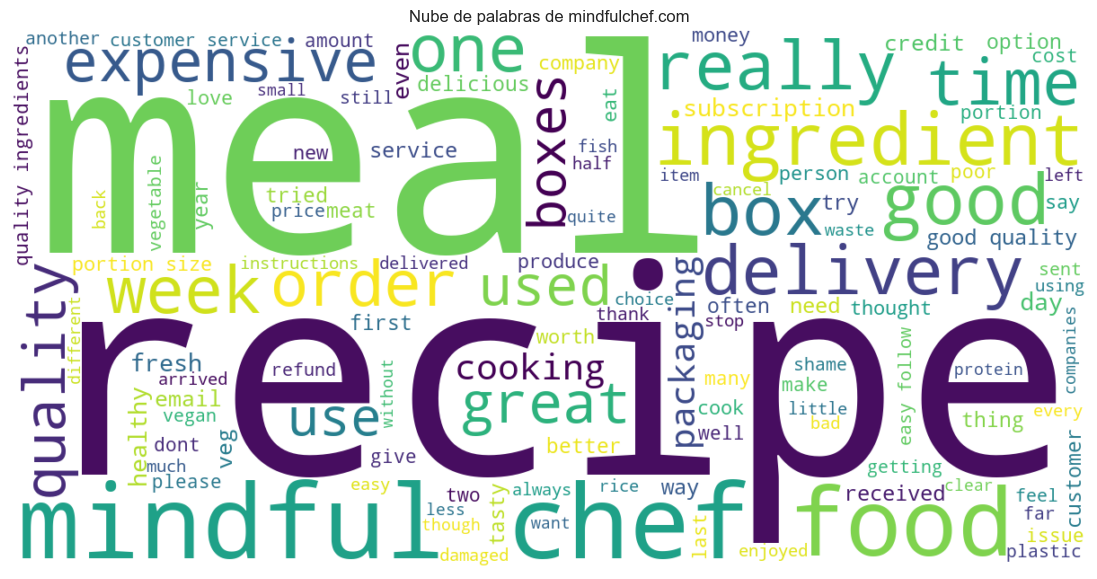

In [35]:
# Por último añadiremos una nube de palabras opcional para apoyar la parte visual de la presentación y dar un contexto más intuitivo sobre los temas que hemos identificado. Esto es especialmente útil para audiencias no técnicas.
if WORDCLOUD_AVAILABLE:
    text_for_wc = " ".join(df_company["clean_text"].tolist())

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=120
    ).generate(text_for_wc)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nube de palabras de mindfulchef.com")
    plt.show()
else:
    print("WordCloud no está instalado en este entorno.")


## 18) Resumen ejecutivo y conclusiones

En esta última parte sintetizo los hallazgos principales del análisis para poder llevarlos después a la presentación.


In [36]:
# Construimos un pequeño resumen automático con los principales hallazgos numéricos
global_company_positive = df_company["sentiment_binary"].mean()
global_sector_positive = df_sector.loc[df_sector["company"].str.lower() != TARGET_COMPANY.lower(), "sentiment_binary"].mean()

best_topic = pivot_compare.sort_values("gap_vs_sector", ascending=False).iloc[0]
worst_topic = pivot_compare.sort_values("gap_vs_sector", ascending=True).iloc[0]

summary = pd.DataFrame({
    "métrica": [
        "Tasa positiva global mindfulchef",
        "Tasa positiva global competencia",
        "Mejor topic relativo",
        "Gap mejor topic",
        "Peor topic relativo",
        "Gap peor topic"
    ],
    "valor": [
        round(global_company_positive, 4),
        round(global_sector_positive, 4),
        best_topic["topic_name"],
        round(best_topic["gap_vs_sector"], 4),
        worst_topic["topic_name"],
        round(worst_topic["gap_vs_sector"], 4)
    ]
})

display(summary)


,métrica,valor
0,Tasa positiva global mindfulchef,0.38
1,Tasa positiva global competencia,0.4759
2,Mejor topic relativo,Product quality and recipes
3,Gap mejor topic,0.0833
4,Peor topic relativo,"Orders, delivery and customer service"
5,Gap peor topic,-0.1197


## Interpretación final

A partir del análisis realizado, se pueden extraer las siguientes conclusiones en términos de negocio:

- **Sentimiento global**: mindfulchef.com presenta una mayor proporción de reseñas negativas en comparación con el sector, lo que indica una brecha relevante en satisfacción del cliente.

- **Topics dominantes**: la mayor parte de la conversación se concentra en dos grandes áreas: la calidad del producto (comida, recetas, ingredientes) y la experiencia operativa (delivery, pedidos y atención al cliente).

- **Fortalezas**: la calidad del producto es claramente el principal punto fuerte de la compañía. Este topic muestra un nivel de satisfacción elevado y superior al de otros aspectos, lo que sugiere que la propuesta de valor del producto está bien posicionada.

- **Debilidades**: los principales problemas se concentran en el ámbito operativo, especialmente en delivery y servicio. Este topic presenta el peor desempeño en términos de sentimiento y es el principal driver de insatisfacción.

- **Análisis de reseñas negativas (delivery)**: el análisis específico de las reseñas negativas revela problemas recurrentes como retrasos en la entrega, pedidos incompletos o incorrectos, incidencias con suscripciones y cobros, y una experiencia deficiente de atención al cliente. Esto indica fallos en procesos operativos más que en el producto en sí.

- **Áreas de mejora**: la principal oportunidad de mejora se encuentra en la optimización de los procesos operativos end-to-end (logística, gestión de pedidos y customer service). Actuar sobre estos puntos tendría un impacto directo en la reducción de reseñas negativas y en el cierre de la brecha con el sector.

En conjunto, el análisis muestra que la compañía cuenta con una base sólida en producto, pero necesita mejorar su ejecución operativa para elevar la satisfacción global del cliente.